# Proyek Analisis Data: Bike-sharing-dataset
- **Nama:** Egi Julian
- **Email:** egyjulian8@gmail.com
- **ID Dicoding:** egijulian

## Menentukan Pertanyaan Bisnis

- Bagaimana pola penyewaan sepeda berbeda di setiap musim, dan musim mana yang memiliki performa terbaik untuk optimalisasi strategi operasional?
- Bagaimana pengaruh suhu udara terhadap pola penyewaan sepeda untuk pengguna casual dan registered, serta kondisi cuaca apa yang paling mendukung peningkatan jumlah penyewaan?

## Import Semua Packages/Library yang Digunakan



In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Data Wrangling

### Gathering Data

In [99]:
day_df = pd.read_csv("Data/day.csv", delimiter=",")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Di data day ini terdapat 16 kolom
- saya membuat data frame baru dengan nama day_df

### Assessing Data

In [100]:
# menampilkan informasi struktur data
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [101]:
# Menampilkan 5 baris pertama
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [102]:
# Menampilkan Statistik deskriptif
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [103]:
# Cek Missing Values
missing_values = day_df.isnull().sum()
print("\nJumlah missing values per kolom:")
print(missing_values)


Jumlah missing values per kolom:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [104]:
# Cek Duplikat
duplicates = day_df.duplicated().sum()
print(f"\nJumlah baris duplikat: {duplicates}")




Jumlah baris duplikat: 0


In [105]:
print("\nTipe data setiap kolom:")
print(day_df.dtypes)


Tipe data setiap kolom:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


**Insight:**
- di info data ini tidak ada yang missing value
- Ketidaksesuaian data type pada dteday, harusnya datetime
- tidak ada juga yang duplicate

### Cleaning Data

In [106]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

**Insight:**
- Mengganti tipe data pada dteday menjadi datetime

## Exploratory Data Analysis (EDA)

### Explore ...

In [107]:
# Melihat statistik deskriptif dasar untuk data numerik
day_df.describe()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


**Insight:**
- diseason terdapat 4 data yaitu 1-4
- weathersit terdapat 3 data yaitu 1-4

In [108]:
# Melihat korelasi antar variabel dengan cnt
day_df.corr(numeric_only=True) ['cnt'].sort_values(ascending=False)

cnt           1.000000
registered    0.945517
casual        0.672804
atemp         0.631066
instant       0.628830
temp          0.627494
yr            0.566710
season        0.406100
mnth          0.279977
weekday       0.067443
workingday    0.061156
holiday      -0.068348
hum          -0.100659
windspeed    -0.234545
weathersit   -0.297391
Name: cnt, dtype: float64

**Insight:**
- ada beberapa kolom data yang berkolerasi dengan cnt, seperti registered, casual dll

In [109]:
# eksplorasi berdasarkan season
day_df.groupby('season')['cnt'].mean().reset_index()

,season,cnt
0,1,2604.132597
1,2,4992.331522
2,3,5644.303191
3,4,4728.162921


**Insight:**
- di dalam season terdapat 4 karakteristik data, dimana angka 1 menunjukkan 'springer', angka 2 menunjukkan 'summer, angka 3 menunjukkan 'fall' , angka 4 menunjukkan 'winter
- rata rata terbanyak terdapat pada musim fall

In [110]:
# eksplorasi berdasarkan weathersit
day_df.groupby('weathersit')['cnt'].mean().reset_index()

,weathersit,cnt
0,1,4876.786177
1,2,4035.862348
2,3,1803.285714


**Insight:**
- di dalam weathersit terdapat 4 karakteristik data, dimana angka 1 menunjukkan 'clear', angka 2 menunjukkan 'mist', angka 3 menunjukkan 'light snow' , angka 4 menunjukkan 'heavy rain'
- rata rata terbanyak terdapat pada weathersit clear
- tidak terdapat data yang menunjukan 4 / heavy rain

In [111]:
# eksplorasi perbandingan workingday dengan casual & registerred
day_df.groupby('workingday')[['casual', 'registered']].mean().reset_index()

,workingday,casual,registered
0,0,1371.134199,2959.034632
1,1,606.570000,3978.250000


**Insight:**
- data ini memiliki 2 karakteristika yaitu 0 untuk hari libur dan 1 untuk hari kerja
- jumlah sepeda tersewa terbanyak yaitu pada saat hari kerja, yang menandakan digunakan untuk berangkat kerja

## Visualization & Explanatory Analysis

### Pertanyaan 1: - Bagaimana pola penyewaan sepeda berbeda di setiap musim, dan musim mana yang memiliki performa terbaik untuk optimalisasi strategi operasional?

##### Plot 1: Bar Chart Rata-rata

In [112]:
# Membuat mapping musim dan menambahkan kolom season_name
season_mapping = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}

# Menambahkan kolom season_name ke dataframe
day_df['season_name'] = day_df['season'].map(season_mapping)

# Menghitung statistik per musim
season_stats = day_df.groupby('season_name')['cnt'].agg(['mean', 'median', 'std']).rename(columns={'mean': 'rata_rata', 'median': 'median', 'std': 'std_dev'})

# Menentukan musim terbaik dan terburuk
best_season = season_stats['rata_rata'].idxmax()
worst_season = season_stats['rata_rata'].idxmin()

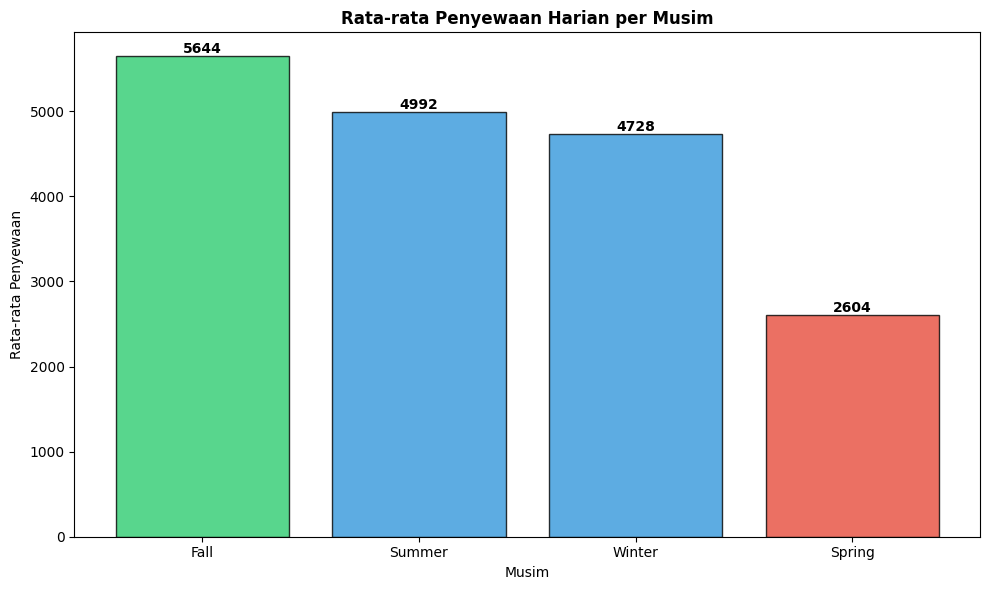

In [113]:

# Menghitung rata-rata penyewaan per musim
season_avg = season_stats['rata_rata'].sort_values(ascending=False)

# Menentukan warna: hijau untuk terbaik, merah untuk terburuk, biru untuk lainnya
colors = []
for musim in season_avg.index:
    if musim == best_season:
        colors.append('#2ecc71')  # Hijau
    elif musim == worst_season:
        colors.append('#e74c3c')  # Merah
    else:
        colors.append('#3498db')  # Biru

# Membuat visualisasi
plt.figure(figsize=(10, 6))

bars = plt.bar(season_avg.index, season_avg.values, 
               color=colors, edgecolor='black', alpha=0.8)

# Menambahkan label di atas setiap bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.0f}',
             ha='center', va='bottom', 
             fontsize=10, fontweight='bold')

plt.title('Rata-rata Penyewaan Harian per Musim', 
          fontsize=12, fontweight='bold')
plt.ylabel('Rata-rata Penyewaan', fontsize=10)
plt.xlabel('Musim', fontsize=10)
plt.tight_layout()
plt.show()

##### Plot 2: Box Plot Distribusi

C:\Users\Acer\AppData\Local\Temp\ipykernel_14800\2286773334.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=day_df, x='season_name', y='cnt',


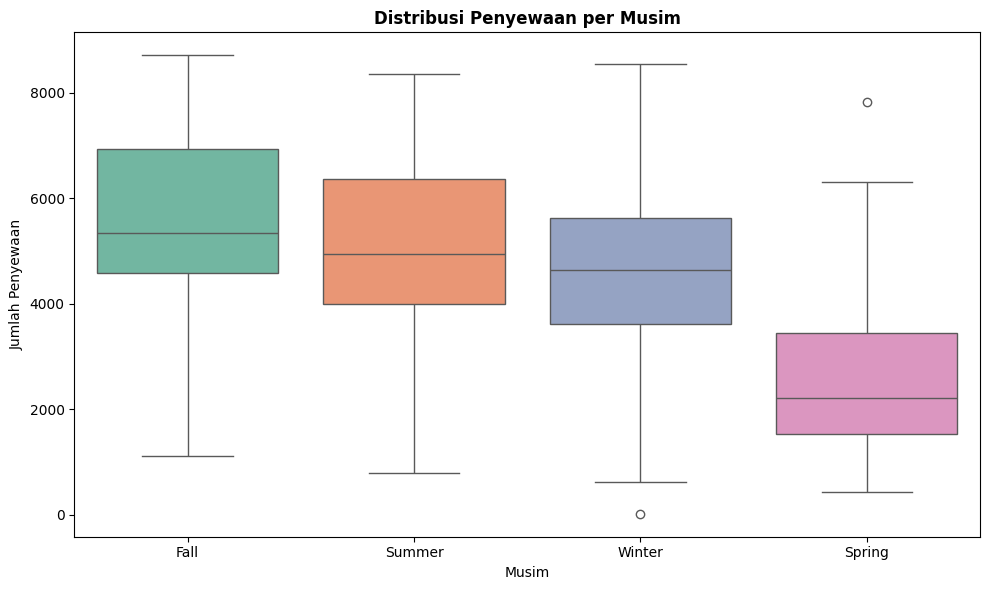

In [114]:
# Mengurutkan musim berdasarkan rata-rata (dari tertinggi)
season_order = season_stats['rata_rata'].sort_values(ascending=False).index

# Membuat box plot
plt.figure(figsize=(10, 6))

sns.boxplot(data=day_df, x='season_name', y='cnt', 
            order=season_order, palette='Set2')

plt.title('Distribusi Penyewaan per Musim', 
          fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Penyewaan', fontsize=10)
plt.xlabel('Musim', fontsize=10)
plt.tight_layout()
plt.show()

##### Plot 3: Stacked Bar Chart - Casual vs Registered

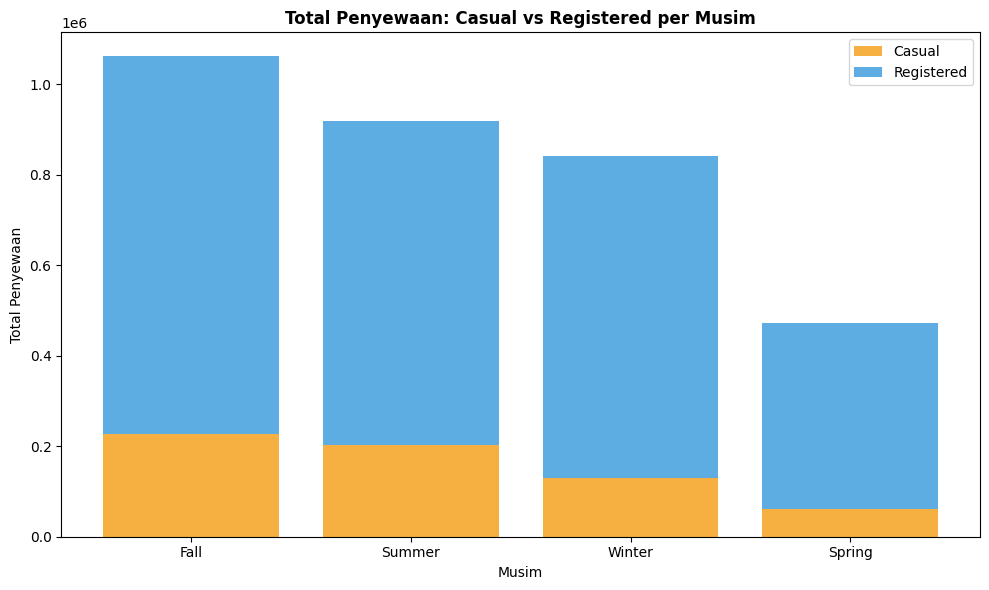

In [115]:
# Menghitung total casual dan registered per musim
season_detail = day_df.groupby('season_name')[['casual', 'registered']].sum()

# Mengurutkan sesuai urutan musim terbaik
season_detail = season_detail.loc[season_order]

# Posisi untuk bar
x = range(len(season_detail))

# Membuat stacked bar chart
plt.figure(figsize=(10, 6))

plt.bar(x, season_detail['casual'], label='Casual', 
        color='#f39c12', alpha=0.8)
plt.bar(x, season_detail['registered'], 
        bottom=season_detail['casual'],
        label='Registered', color='#3498db', alpha=0.8)

# Set label untuk sumbu X
plt.xticks(x, season_detail.index)

plt.title('Total Penyewaan: Casual vs Registered per Musim', 
          fontsize=12, fontweight='bold')
plt.ylabel('Total Penyewaan', fontsize=10)
plt.xlabel('Musim', fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()

##### Plot 4: Line Chart - Trend Bulanan per Musim

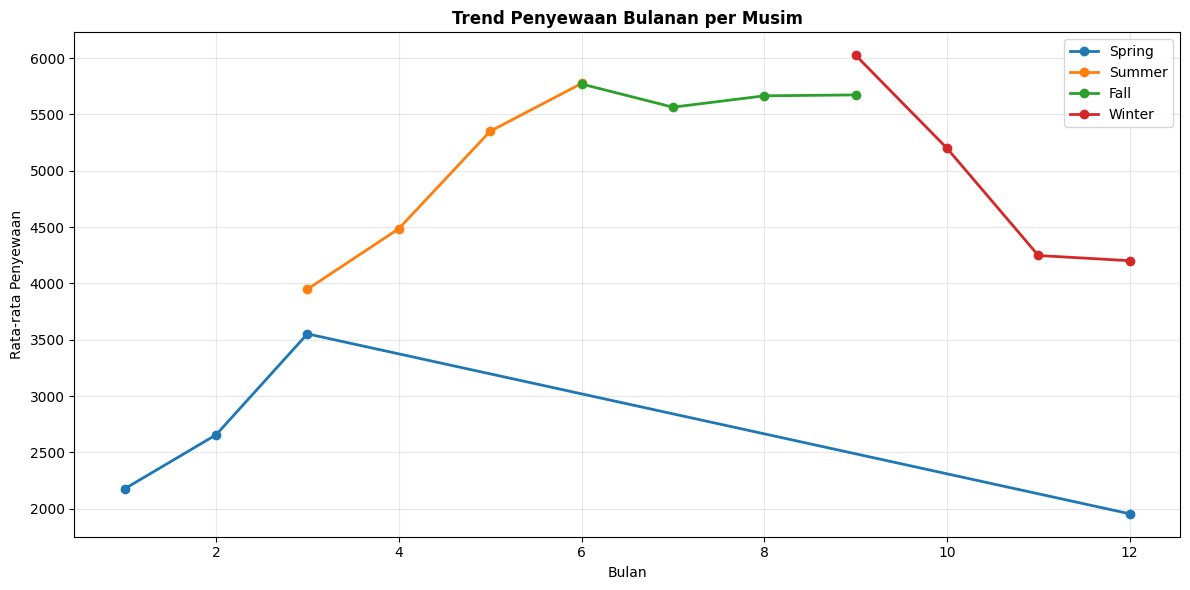

In [116]:
# Menghitung rata-rata penyewaan per bulan dan musim
monthly_avg = day_df.groupby(['mnth', 'season_name'])['cnt'].mean().reset_index()

# Membuat line chart
plt.figure(figsize=(12, 6))

# Loop untuk setiap musim
for season in season_mapping.values():
    season_data = monthly_avg[monthly_avg['season_name'] == season]
    plt.plot(season_data['mnth'], season_data['cnt'], 
             marker='o', label=season, linewidth=2)

plt.title('Trend Penyewaan Bulanan per Musim', 
          fontsize=12, fontweight='bold')
plt.ylabel('Rata-rata Penyewaan', fontsize=10)
plt.xlabel('Bulan', fontsize=10)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:**
- Fall adalah musim dengan performa terbaik (5644 penyewaan/hari)
- Spring memiliki performa terendah (2604 penyewaan/hari)
- Terdapat gap signifikan sebesar 116.7% antara kedua musim
- Casual users lebih sensitif terhadap musim
- Registered users lebih stabil sepanjang tahun
- Tingkatkan inventory sepeda saat musim Fall
- Implementasi promo/diskon saat Spring untuk boost demand
- Alokasi maintenance di Spring (demand rendah)
- Rekrutmen staff seasonal untuk Fall

### Pertanyaan 2: Bagaimana pengaruh suhu udara terhadap pola penyewaan sepeda untuk pengguna casual dan registered, serta kondisi cuaca apa yang paling mendukung peningkatan jumlah penyewaan?.

##### Plot 1: Scatter Plot dengan Trendline

In [117]:
# Menghitung korelasi antara temp dengan casual dan registered
corr_casual = day_df['temp'].corr(day_df['casual'])
corr_registered = day_df['temp'].corr(day_df['registered'])

print(f"Korelasi Temp vs Casual: {corr_casual:.3f}")
print(f"Korelasi Temp vs Registered: {corr_registered:.3f}")

Korelasi Temp vs Casual: 0.543
Korelasi Temp vs Registered: 0.540


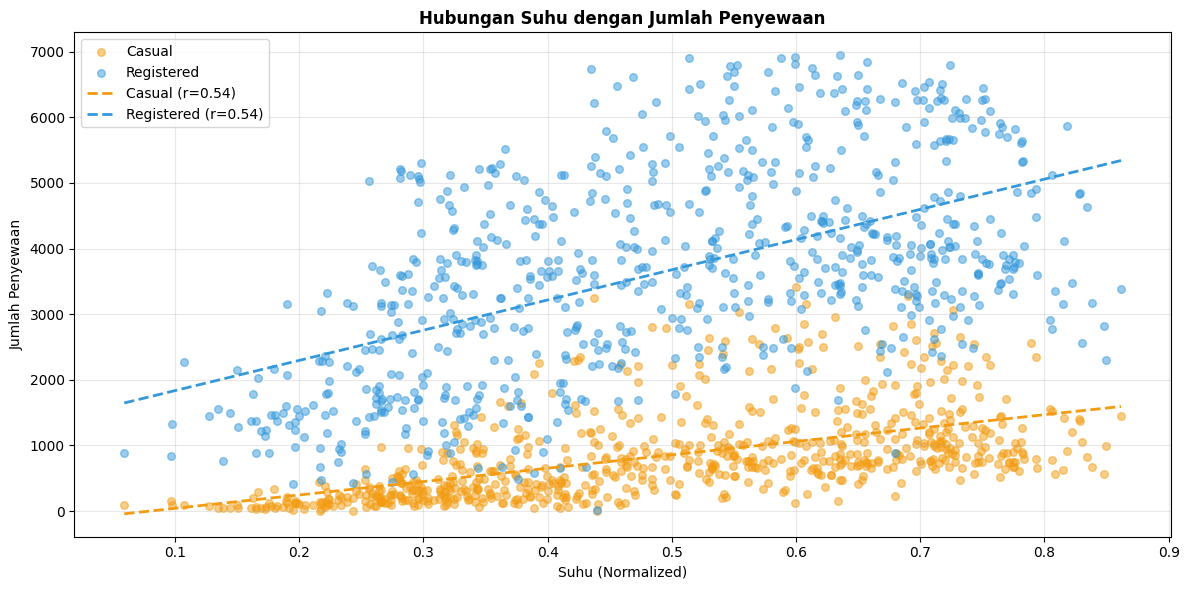

In [118]:
# Membuat scatter plot
plt.figure(figsize=(12, 6))

# Scatter points
plt.scatter(day_df['temp'], day_df['casual'], 
            alpha=0.5, color='#f39c12', label='Casual', s=30)
plt.scatter(day_df['temp'], day_df['registered'], 
            alpha=0.5, color='#3498db', label='Registered', s=30)

# Menambahkan trendline
z_casual = np.polyfit(day_df['temp'], day_df['casual'], 1)
z_registered = np.polyfit(day_df['temp'], day_df['registered'], 1)
p_casual = np.poly1d(z_casual)
p_registered = np.poly1d(z_registered)

temp_range = np.linspace(day_df['temp'].min(), day_df['temp'].max(), 100)
plt.plot(temp_range, p_casual(temp_range), 
         color='#f39c12', linewidth=2, linestyle='--', 
         label=f'Casual (r={corr_casual:.2f})')
plt.plot(temp_range, p_registered(temp_range), 
         color='#3498db', linewidth=2, linestyle='--', 
         label=f'Registered (r={corr_registered:.2f})')

plt.title('Hubungan Suhu dengan Jumlah Penyewaan', fontsize=12, fontweight='bold')
plt.xlabel('Suhu (Normalized)', fontsize=10)
plt.ylabel('Jumlah Penyewaan', fontsize=10)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Plot 2: Bar Chart - Casual vs Registered per Kategori Suhu

In [119]:
# Membuat kategori suhu (Low, Medium, High)
day_df['temp_category'] = pd.cut(day_df['temp'], bins=3, labels=['Low', 'Medium', 'High'])

C:\Users\Acer\AppData\Local\Temp\ipykernel_14800\2788684443.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_analysis = day_df.groupby('temp_category').agg({


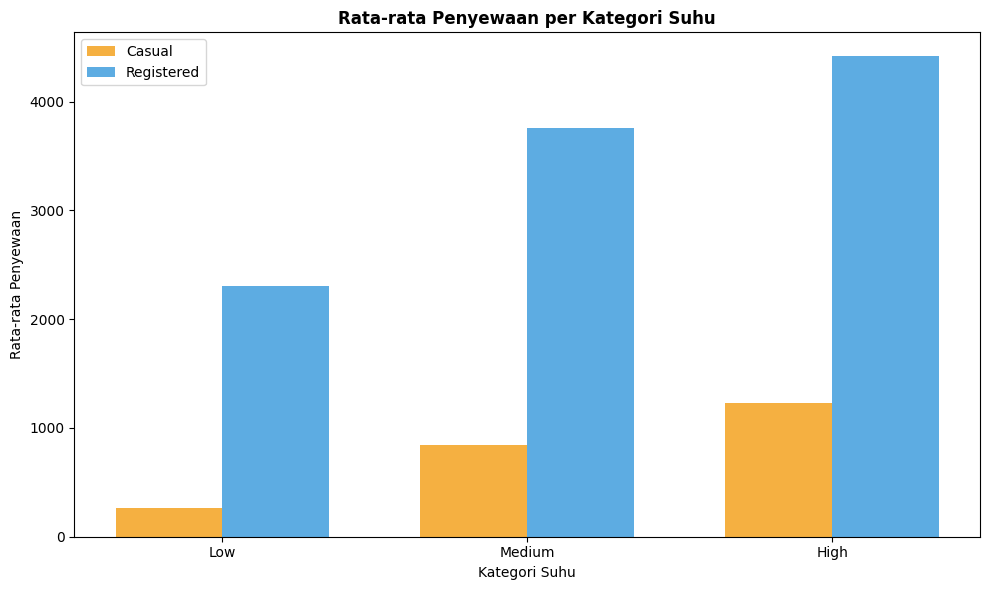

In [120]:
# Menghitung rata-rata per kategori suhu
temp_analysis = day_df.groupby('temp_category').agg({
    'casual': 'mean',
    'registered': 'mean'
}).round(0)

# Posisi bar
x = range(len(temp_analysis))
width = 0.35

# Membuat grouped bar chart
plt.figure(figsize=(10, 6))

plt.bar([i - width/2 for i in x], temp_analysis['casual'], 
        width, label='Casual', color='#f39c12', alpha=0.8)
plt.bar([i + width/2 for i in x], temp_analysis['registered'],
        width, label='Registered', color='#3498db', alpha=0.8)

plt.xticks(x, temp_analysis.index)
plt.title('Rata-rata Penyewaan per Kategori Suhu', 
          fontsize=12, fontweight='bold')
plt.ylabel('Rata-rata Penyewaan', fontsize=10)
plt.xlabel('Kategori Suhu', fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()

##### Plot 3: Box Plot - Casual Users

C:\Users\Acer\AppData\Local\Temp\ipykernel_14800\738792204.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=day_df, x='temp_category', y='casual',


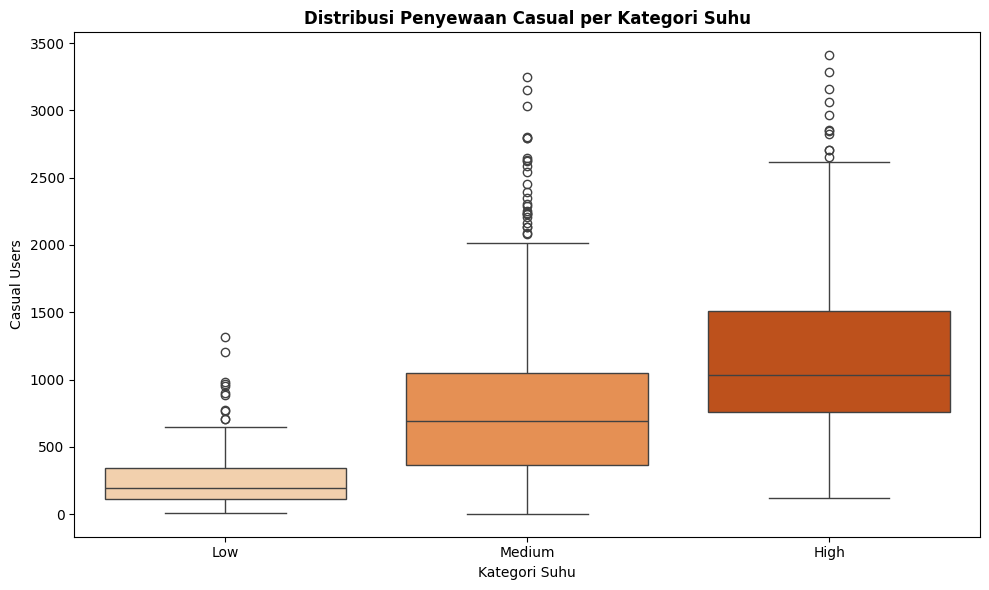

In [121]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=day_df, x='temp_category', y='casual', 
            palette='Oranges')

plt.title('Distribusi Penyewaan Casual per Kategori Suhu',
          fontsize=12, fontweight='bold')
plt.ylabel('Casual Users', fontsize=10)
plt.xlabel('Kategori Suhu', fontsize=10)
plt.tight_layout()
plt.show()

##### Plot 4: Box Plot - Registered Users

C:\Users\Acer\AppData\Local\Temp\ipykernel_14800\476277831.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=day_df, x='temp_category', y='registered',


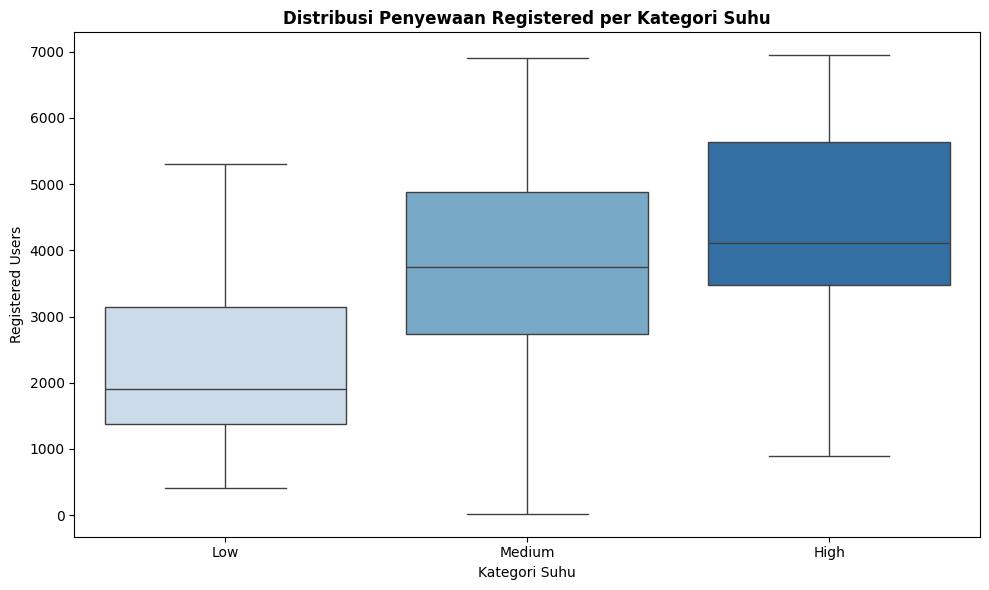

In [122]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=day_df, x='temp_category', y='registered',
            palette='Blues')

plt.title('Distribusi Penyewaan Registered per Kategori Suhu',
          fontsize=12, fontweight='bold')
plt.ylabel('Registered Users', fontsize=10)
plt.xlabel('Kategori Suhu', fontsize=10)
plt.tight_layout()
plt.show()

In [123]:
# Menentukan kondisi optimal berdasarkan data analisis
optimal_temp_casual = temp_analysis['casual'].idxmax()
optimal_temp_registered = temp_analysis['registered'].idxmax()

**Insight:**
- Casual users memiliki Korelasi sedang (r=0.543) yang berarti Suhu memiliki pengaruh cukup signifikan terhadap casual
- Registered users memiliki Korelasi sedang (r=0.540) yang berarti Registered lebih stabil terhadap perubahan suhu
- Casual memiliki Performa terbaik saat cuaca High
- Registered memilki Performa terbaik saat cuaca High
- Casual users LEBIH SENSITIF terhadap cuaca dibanding registered
- Targetkan casual users dengan promo saat cuaca High
- Gunakan forecast cuaca untuk prediksi demand casual users
- Fokus retention program untuk registered (tidak terpengaruh cuaca)
- Seasonal campaign: boost casual di musim hangat, maintain registered sepanjang tahun

## Analisis Lanjutan (Opsional)

## Conclusion

- Conclution pertanyaan 1 : Pola musiman memiliki **pengaruh sangat signifikan** terhadap penyewaan sepeda. Strategi kunci adalah **memaksimalkan profit saat Fall**, **meningkatkan demand saat Spring**, dan **mengkonversi casual users** menjadi registered untuk stabilitas revenue.
- Conclution pertanyaan 2 : Suhu memiliki **pengaruh signifikan** terhadap penyewaan, terutama untuk casual users. **Kondisi hangat (20-28°C)** adalah sweet spot untuk demand. Dengan memanfaatkan weather forecast dan differentiated strategy untuk casual vs registered users, perusahaan dapat **meningkatkan revenue predictability** dan **operational efficiency**.
